In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [11]:
df = pd.read_csv("../data/customer_service_interactions.csv")

df.head()

,Interaction_ID,Customer_ID,Interaction_Date,Channel,Team,Customer_Segment,Issue_Category,Priority,Agent_ID,Previous_Interactions,Response_Time_Min,Resolution_Time_Min,Escalated,FCR,CSAT,Resolution_Status,SLA_Breached
0,INT122055,CUST15601,2025-01-01 00:00:00,Email,Tier 2 Support,Premium,Product Inquiry,Medium,AG145,0,189.7,113.4,1,1,3.0,Pending,1
1,INT108664,CUST13753,2025-01-01 01:00:00,Phone,Technical Support,Consumer,Refund,Medium,AG126,0,38.9,155.5,0,1,4.0,Resolved,0
2,INT125862,CUST11918,2025-01-01 01:00:00,Chat,Technical Support,Consumer,Complaint,Medium,AG177,3,30.5,140.3,0,1,4.0,Pending,0
3,INT102482,CUST11863,2025-01-01 01:00:00,Email,Billing,Consumer,Account Access,Low,AG118,3,193.4,109.2,1,1,4.0,Resolved,0
4,INT102330,CUST18368,2025-01-01 01:00:00,Phone,Tier 2 Support,Consumer,Account Access,Low,AG134,6,36.9,134.4,0,1,5.0,Resolved,0


In [12]:
df.shape

(30000, 17)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Interaction_ID         30000 non-null  str    
 1   Customer_ID            30000 non-null  str    
 2   Interaction_Date       30000 non-null  str    
 3   Channel                30000 non-null  str    
 4   Team                   30000 non-null  str    
 5   Customer_Segment       29910 non-null  str    
 6   Issue_Category         30000 non-null  str    
 7   Priority               30000 non-null  str    
 8   Agent_ID               30000 non-null  str    
 9   Previous_Interactions  30000 non-null  int64  
 10  Response_Time_Min      29850 non-null  float64
 11  Resolution_Time_Min    30000 non-null  float64
 12  Escalated              30000 non-null  int64  
 13  FCR                    30000 non-null  int64  
 14  CSAT                   29760 non-null  float64
 15  Resolution_St

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Interaction_ID,30000,30000,INT122055,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,30000,8697,CUST14015,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Interaction_Date,30000,12677,2025-04-11 15:00:00,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,30000,5,Phone,8367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Team,30000,5,Tier 1 Support,10296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Segment,29910,4,Consumer,15576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_Category,30000,8,Technical Issue,5293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority,30000,4,Medium,13693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent_ID,30000,80,AG125,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Previous_Interactions,30000.0,NaN,NaN,NaN,2.200233,1.486634,0.0,1.0,2.0,3.0,11.0


In [15]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

CSAT                 240
Response_Time_Min    150
Customer_Segment      90
dtype: int64

In [16]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0]

CSAT                 0.8
Response_Time_Min    0.5
Customer_Segment     0.3
dtype: float64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["Interaction_ID"].duplicated().sum()

np.int64(0)

In [19]:
df["Interaction_Date"] = pd.to_datetime(df["Interaction_Date"])

In [20]:
df["Interaction_Date"].dtype

dtype('<M8[us]')

In [21]:
df["Date"] = df["Interaction_Date"].dt.date
df["Year"] = df["Interaction_Date"].dt.year
df["Month"] = df["Interaction_Date"].dt.month
df["Month_Name"] = df["Interaction_Date"].dt.month_name()
df["Year_Month"] = df["Interaction_Date"].dt.to_period("M").astype(str)
df["Day_Name"] = df["Interaction_Date"].dt.day_name()

In [22]:
df.isnull().sum()

Interaction_ID             0
Customer_ID                0
Interaction_Date           0
Channel                    0
Team                       0
Customer_Segment          90
Issue_Category             0
Priority                   0
Agent_ID                   0
Previous_Interactions      0
Response_Time_Min        150
Resolution_Time_Min        0
Escalated                  0
FCR                        0
CSAT                     240
Resolution_Status          0
SLA_Breached               0
Date                       0
Year                       0
Month                      0
Month_Name                 0
Year_Month                 0
Day_Name                   0
dtype: int64

In [23]:
df["CSAT"] = df["CSAT"].fillna(df["CSAT"].median())

In [24]:
df["Response_Time_Min"] = df["Response_Time_Min"].fillna(
    df["Response_Time_Min"].median()
)

In [25]:
df["Customer_Segment"] = df["Customer_Segment"].fillna("Unknown")

In [26]:
df.isnull().sum()

Interaction_ID           0
Customer_ID              0
Interaction_Date         0
Channel                  0
Team                     0
Customer_Segment         0
Issue_Category           0
Priority                 0
Agent_ID                 0
Previous_Interactions    0
Response_Time_Min        0
Resolution_Time_Min      0
Escalated                0
FCR                      0
CSAT                     0
Resolution_Status        0
SLA_Breached             0
Date                     0
Year                     0
Month                    0
Month_Name               0
Year_Month               0
Day_Name                 0
dtype: int64

In [27]:
for col in [
    "Channel",
    "Team",
    "Customer_Segment",
    "Issue_Category",
    "Priority",
    "Resolution_Status"
]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Channel ---
Channel
Phone           8367
Chat            7580
Email           7161
Web             3810
Social Media    3082
Name: count, dtype: int64

--- Team ---
Team
Tier 1 Support       10296
Technical Support     6632
Tier 2 Support        5277
Billing               4258
Retention             3537
Name: count, dtype: int64

--- Customer_Segment ---
Customer_Segment
Consumer          15576
Small Business     5931
Premium            4518
Enterprise         3885
Unknown              90
Name: count, dtype: int64

--- Issue_Category ---
Issue_Category
Technical Issue    5293
Product Inquiry    4553
Billing            4134
Account Access     3911
Delivery           3535
Refund             3057
Cancellation       2759
Complaint          2758
Name: count, dtype: int64

--- Priority ---
Priority
Medium      13693
Low          8853
High         5901
Critical     1553
Name: count, dtype: int64

--- Resolution_Status ---
Resolution_Status
Resolved       25531
Pending         3647
Transf

In [28]:
total_interactions = len(df)

print("Total Interactions:", total_interactions)

Total Interactions: 30000


In [29]:
avg_csat = df["CSAT"].mean()

print("Average CSAT:", round(avg_csat, 2))

Average CSAT: 4.23


In [30]:
fcr_rate = df["FCR"].mean() * 100

print("FCR Rate:", round(fcr_rate, 2), "%")

FCR Rate: 78.75 %


In [31]:
escalation_rate = df["Escalated"].mean() * 100

print("Escalation Rate:", round(escalation_rate, 2), "%")

Escalation Rate: 17.89 %


In [32]:
sla_breach_rate = df["SLA_Breached"].mean() * 100

print("SLA Breach Rate:", round(sla_breach_rate, 2), "%")

SLA Breach Rate: 25.49 %


In [33]:
avg_response = df["Response_Time_Min"].mean()

print("Average Response Time:",
      round(avg_response, 2), "minutes")

Average Response Time: 87.99 minutes


In [34]:
avg_resolution = df["Resolution_Time_Min"].mean()

print("Average Resolution Time:",
      round(avg_resolution, 2), "minutes")

Average Resolution Time: 107.03 minutes


In [35]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Interactions",
        "Average CSAT",
        "FCR %",
        "Escalation %",
        "SLA Breach %",
        "Avg Response Time",
        "Avg Resolution Time"
    ],
    "Value": [
        total_interactions,
        round(avg_csat, 2),
        round(fcr_rate, 2),
        round(escalation_rate, 2),
        round(sla_breach_rate, 2),
        round(avg_response, 2),
        round(avg_resolution, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Interactions,30000.00
1,Average CSAT,4.23
2,FCR %,78.75
3,Escalation %,17.89
4,SLA Breach %,25.49
5,Avg Response Time,87.99
6,Avg Resolution Time,107.03


In [36]:
channel_analysis = (
    df.groupby("Channel")
      .agg(
          Interactions=("Interaction_ID", "count"),
          Avg_CSAT=("CSAT", "mean"),
          FCR=("FCR", "mean"),
          Escalation_Rate=("Escalated", "mean"),
          Avg_Response_Time=("Response_Time_Min", "mean"),
          Avg_Resolution_Time=("Resolution_Time_Min", "mean")
      )
      .reset_index()
)

channel_analysis

,Channel,Interactions,Avg_CSAT,FCR,Escalation_Rate,Avg_Response_Time,Avg_Resolution_Time
0,Chat,7580,4.456596,0.789050,0.138391,37.337546,106.490541
1,Email,7161,3.639436,0.771121,0.291021,211.498045,106.506633
2,Phone,8367,4.462412,0.798375,0.133142,40.703968,107.219039
3,Social Media,3082,4.233939,0.787151,0.168397,91.602239,108.556230
4,Web,3810,4.375066,0.791864,0.157480,57.584777,107.435538


In [37]:
channel_analysis["FCR"] *= 100
channel_analysis["Escalation_Rate"] *= 100

channel_analysis.round(2)


,Channel,Interactions,Avg_CSAT,FCR,Escalation_Rate,Avg_Response_Time,Avg_Resolution_Time
0,Chat,7580,4.46,78.91,13.84,37.34,106.49
1,Email,7161,3.64,77.11,29.10,211.50,106.51
2,Phone,8367,4.46,79.84,13.31,40.70,107.22
3,Social Media,3082,4.23,78.72,16.84,91.60,108.56
4,Web,3810,4.38,79.19,15.75,57.58,107.44


In [38]:
issue_analysis = (
    df.groupby("Issue_Category")
      .agg(
          Interactions=("Interaction_ID", "count"),
          Avg_CSAT=("CSAT", "mean"),
          Escalation_Rate=("Escalated", "mean"),
          FCR=("FCR", "mean"),
          Avg_Resolution_Time=("Resolution_Time_Min", "mean")
      )
      .reset_index()
)

issue_analysis["Escalation_Rate"] *= 100
issue_analysis["FCR"] *= 100

issue_analysis.sort_values(
    "Escalation_Rate",
    ascending=False
).round(2)

,Issue_Category,Interactions,Avg_CSAT,Escalation_Rate,FCR,Avg_Resolution_Time
3,Complaint,2758,4.19,22.52,74.18,108.08
2,Cancellation,2759,4.22,21.93,77.82,106.30
0,Account Access,3911,4.22,18.03,80.11,107.86
4,Delivery,3535,4.24,17.40,81.39,107.27
5,Product Inquiry,4553,4.25,17.15,81.64,107.56
7,Technical Issue,5293,4.21,17.06,72.36,106.42
6,Refund,3057,4.26,15.80,82.01,106.22
1,Billing,4134,4.24,15.80,81.49,106.62


In [39]:
team_analysis = (
    df.groupby("Team")
      .agg(
          Interactions=("Interaction_ID", "count"),
          Avg_CSAT=("CSAT", "mean"),
          FCR=("FCR", "mean"),
          Escalation_Rate=("Escalated", "mean"),
          Avg_Response_Time=("Response_Time_Min", "mean"),
          Avg_Resolution_Time=("Resolution_Time_Min", "mean"),
          SLA_Breach_Rate=("SLA_Breached", "mean")
      )
      .reset_index()
)

team_analysis["FCR"] *= 100
team_analysis["Escalation_Rate"] *= 100
team_analysis["SLA_Breach_Rate"] *= 100

team_analysis.round(2)

,Team,Interactions,Avg_CSAT,FCR,Escalation_Rate,Avg_Response_Time,Avg_Resolution_Time,SLA_Breach_Rate
0,Billing,4258,4.26,78.49,18.39,87.01,90.71,24.92
1,Retention,3537,4.22,78.85,17.90,87.71,106.55,25.02
2,Technical Support,6632,4.15,79.04,19.50,87.35,158.97,25.29
3,Tier 1 Support,10296,4.30,78.90,16.27,88.19,70.12,25.84
4,Tier 2 Support,5277,4.19,78.25,18.61,89.42,127.26,25.81


In [40]:
monthly_analysis = (
    df.groupby("Year_Month")
      .agg(
          Interactions=("Interaction_ID", "count"),
          Avg_CSAT=("CSAT", "mean"),
          FCR=("FCR", "mean"),
          Escalation_Rate=("Escalated", "mean"),
          Avg_Response_Time=("Response_Time_Min", "mean")
      )
      .reset_index()
)

monthly_analysis["FCR"] *= 100
monthly_analysis["Escalation_Rate"] *= 100

monthly_analysis.round(2)

,Year_Month,Interactions,Avg_CSAT,FCR,Escalation_Rate,Avg_Response_Time
0,2025-01,1543,4.21,79.46,17.30,89.52
1,2025-02,1445,4.22,78.48,16.82,88.55
2,2025-03,1539,4.24,81.09,18.06,87.61
3,2025-04,1459,4.24,78.62,17.07,87.22
4,2025-05,1514,4.26,76.82,17.97,88.06
5,2025-06,1475,4.23,78.71,17.02,87.26
6,2025-07,1518,4.23,79.78,17.39,86.62
7,2025-08,1554,4.20,77.61,18.08,89.20
8,2025-09,1483,4.26,78.08,18.14,85.05
9,2025-10,1580,4.21,77.72,18.16,89.95


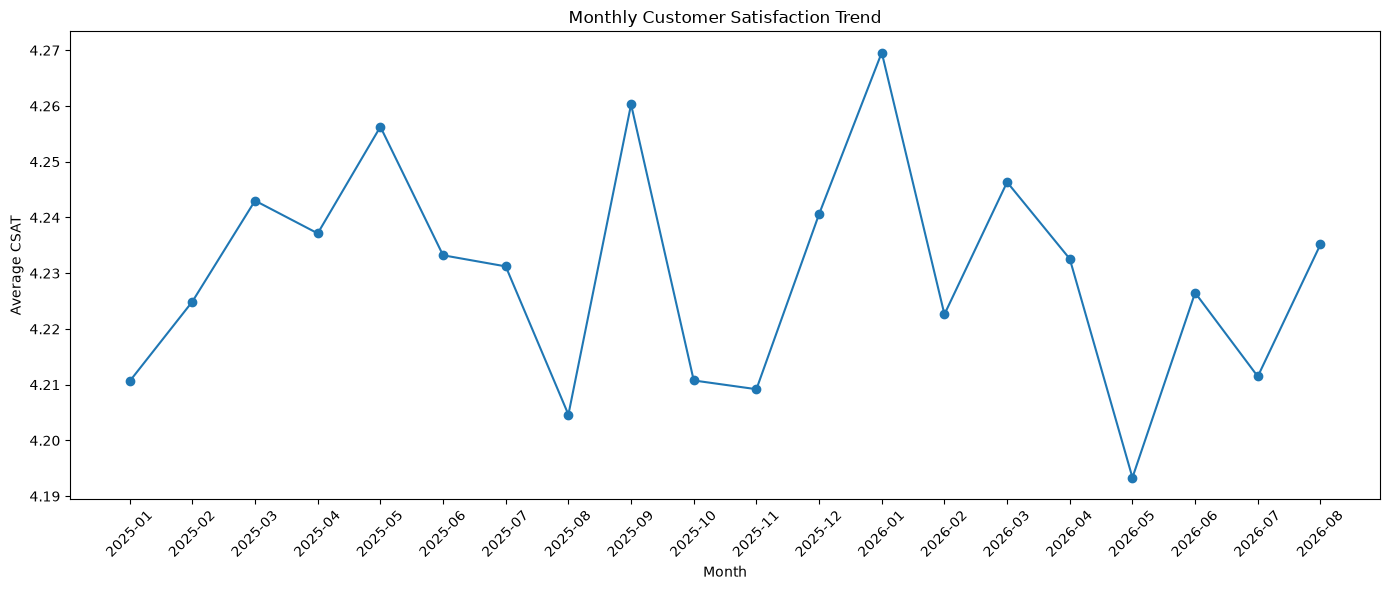

In [41]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Avg_CSAT"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average CSAT")
plt.title("Monthly Customer Satisfaction Trend")

plt.tight_layout()
plt.show()

In [44]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/customer_service_cleaned.csv",
    index=False
)